In [1]:
import os
import time
import warnings
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, randomized_svd, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from umap.umap_ import UMAP
# Numba (in umap.py) needs NumPy 2.2 or less
import cv2
import joblib

warnings.filterwarnings("ignore")

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.9.0   |
| pandas            | 3.0.3   |
| numpy             | 2.1.0   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.11.1  |
| code formatter    | black 25.1.0  |

In [2]:
notebook_time = time.time()

* All info is represented in both ru and eng. Ru versions is hidden

#### 1. Answer the questions from the Preamble and Introduction

##### 1.1 For which of the models already studied is the curse of dimensionality relevant and explain why.

<!-- Главная статистическая проблема KNN-классификаторов – то, что они плохо работают для входных данных высокой размерности. <br>
Суть проблемы состоит в том, что пространственный объем экспоненциально растет с увеличением размерности, <br>поэтому для поиска ближайшего соседа, возможно, придется заглянуть очень далеко (source №1).

K-means также использует в алгоритме рассчет расстояния, поэтому подвержен проклятью размерности. -->

The main statistical problem with KNN classifiers is that they perform poorly on high-dimensional input data. <br>
The problem is that spatial volume grows exponentially with increasing dimensionality, <br>so finding the nearest neighbor may require looking very far (source #1).<br>

K-means also uses distance calculations in its algorithm, and is therefore susceptible to the curse of dimensionality.

##### 1.2 What is the difference between Principal component analysis (PCA) and Singular Value Decomposition (SVD)?

<!-- | Аспект | Principal Component Analysis (PCA) | Singular Value Decomposition (SVD) |
|--------|-----------------------------------|-----------------------------------|
| **Сущность метода** | Статистический метод, находящий ортогональные направления максимальной дисперсии в центрированных данных | Матричное разложение, факторизующее любую матрицу $A$ как: $A = U \Sigma V^T$ |
| **Математическая связь** | Для центрированной по столбцам матрицы данных $X$ выполнение PCA эквивалентно применению SVD:<br>$X = U \Sigma V^T$ | SVD обеспечивает вычислительную основу для PCA |
| **Компоненты PCA через SVD** | **Главные компоненты** = матрица правых сингулярных векторов $V$<br>**Объясненная дисперсия** для каждой компоненты задается квадратами сингулярных значений из $\Sigma$ | **$V$** - направления главных компонент<br>**$\Sigma$** - сингулярные значения, связанные с дисперсией |
| **Расчет дисперсии** | Дисперсия, объясняемая k-й компонентой: $\displaystyle \frac{\sigma_k^2}{n-1}$<br>где $\sigma_k$ - k-й диагональный элемент $\Sigma$, $n$ - количество наблюдений | Квадраты сингулярных значений $\sigma_k^2$ пропорциональны объясненной дисперсии |
| **Ключевое отличие** | **Статистическое приложение**: анализ дисперсии и снижение размерности | **Вычислительный метод**: матричная факторизация, используемая для реализации PCA |
| **Требования к данным** | Данные должны быть центрированы (среднее = 0) | Может работать с любыми данными, но для PCA требуется центрирование |
| **Результат** | Ортогональные направления максимальной дисперсии + объясненная дисперсия для каждой компоненты | Три матрицы: $U$ (левые векторы), $\Sigma$ (сингулярные значения), $V^T$ (правые векторы) |
| **Интерпретация** | Статистическая: компоненты как направления максимальной изменчивости данных | Алгебраическая: разложение на ортогональные компоненты и сингулярные значения |
| **Вычислительная реализация** | На практике PCA часто реализуется через SVD центрированной матрицы данных | Прямое матричное разложение без статистических предположений |

**PCA** - это статистическая методика анализа данных, тогда как **SVD** - это вычислительный алгоритм, который для центрированных данных позволяет получить главные компоненты и объясненную дисперсию.<br>
**В одном предложении:** PCA - это статистическое приложение для анализа дисперсии; SVD - вычислительный метод для его реализации на центрированных данных. -->

| Aspect | Principal Component Analysis (PCA) | Singular Value Decomposition (SVD) |
|--------|-----------------------------------|-----------------------------------|
| **Essence of the Method** | A statistical method that finds orthogonal directions of maximum variance in centered data | A matrix decomposition that factorizes any matrix $A$ as: $A = U \Sigma V^T$ |
| **Mathematical Relationship** | For a column-centered data matrix $X$, performing PCA is equivalent to applying SVD:<br>$X = U \Sigma V^T$ | SVD provides the computational foundation for PCA |
| **PCA Components via SVD** | **Principal Components** = matrix of right singular vectors $V$<br>**Explained variance** for each component is given by the squares of the singular values ​​from $\Sigma$ | **$V$** are the directions of the principal components<br>**$\Sigma$** are the singular values ​​associated with the variance |
| **Calculating Variance** | Variance explained by the k-th component: $\displaystyle \frac{\sigma_k^2}{n-1}$<br>where $\sigma_k$ is the k-th diagonal element of $\Sigma$, $n$ is the number of observations | The squares of the singular values ​​$\sigma_k^2$ are proportional to the explained variance |
| **Key Difference** | **Statistical Appendix**: Analysis of Variance and Dimensionality Reduction | **Computational Method**: Matrix factorization used to implement PCA |
| **Data Requirements** | Data must be centered (mean = 0) | Can be used with any data, but centering is required for PCA |
| **Result** | Orthogonal directions of maximum variance + explained variance for each component | Three matrices: $U$ (left vectors), $\Sigma$ (singular values), $V^T$ (right vectors) |
| **Interpretation** | Statistical: components as directions of maximum variability in the data | Algebraic: decomposition into orthogonal components and singular values ​​|
| **Computational Implementation** | In practice, PCA is often implemented via the SVD of a centered data matrix | Direct matrix decomposition without statistical assumptions |

**PCA** is a statistical data analysis technique, while **SVD** is a computational algorithm that, for centered data, yields principal components and explained variance.<br>
**In one sentence:** PCA is a statistical application of variance analysis; SVD is a computational method for implementing it on centered data.

##### 1.3 What is the difference between Non-Negative Matrix Factorization (NMF) and Singular Value Decomposition (SVD)?

<!-- | Характеристика | Singular Value Decomposition (SVD) | Non-Negative Matrix Factorization (NMF) |
|----------------|-----------------------------------|----------------------------------------|
| **Математическое определение** | $ A_{m \times n} = U_{m \times m} \Sigma_{m \times n} V^T_{n \times n} $<br>**Усеченный SVD:**<br>$ A_{m \times n} \approx U_{m \times k} \Sigma_{k \times k} V^T_{k \times n} $ | $ A_{m \times n} \approx W_{m \times k} H_{k \times n} $<br>где $ W \ge 0 $ и $ H \ge 0 $ |
| **Компоненты** | **$U$** - Левые сингулярные векторы: Ортогональная матрица ($U^TU=I$). <br>Столбцы представляют "скрытые темы" в пространстве объектов (например, документов)<br>**$\Sigma$** - Сингулярные значения: Диагональная матрица с неотрицательными сингулярными значениями, <br>упорядоченными по убыванию: $\sigma_1 \ge \sigma_2 \ge ... \ge 0$. Представляют важность каждой "темы". <br>Квадрат сингулярного значения - дисперсия, объясняемая компонентой<br>**$V^T$** - Правые сингулярные векторы: Транспонированная ортогональная матрица ($V^TV=I$). Строки представляют "скрытые темы" в пространстве признаков (например, терминов) | **$W$** - Матрица базисов/компонент: Содержит k базовых компонент (например, "основные темы" в текстах, "базовые лица" в изображениях). Каждый столбец - один базис<br>**$H$** - Матрица коэффициентов/весов: Содержит веса (коэффициенты), показывающие, как каждый базис из $W$ комбинируется для реконструкции исходного объекта (строки матрицы $A$) |
| **Интерпретация компонентов** | **$U[i,j]$** - вес i-го объекта в j-й теме<br>**$V^T[i,j]$** - вес j-го признака в i-й теме<br>**$\sigma_i$** - важность i-й темы, $\sigma_i^2$ - объясняемая дисперсия | **$W[i,j]$** - вклад i-го признака в j-й базис<br>**$H[i,j]$** - вес i-го базиса в j-м объекте |
| **Ограничения на данные** | Работает с любыми вещественными числами (положительные, отрицательные, нули) | Только неотрицательные входные данные и неотрицательные множители |
| **Интерпретируемость** | Низкая: компоненты могут быть отрицательными,<br> что усложняет интерпретацию ("отрицательные веса" не имеют физического смысла) | Высокая: компоненты неотрицательны, рассматриваются как "части целого" (темы, ингредиенты, базовые паттерны) |
| **Тип разложения** | Аналитическое, точное решение<br>Аппроксимация в евклидовом и фробениусом пространстве | Итеративное, численное решение<br>Аппроксимация в пространстве с неотрицательными ограничениями |
| **Математические свойства** | Ортогональные компоненты ($U^TU=I$, $V^TV=I$)<br>Обобщенная базовая система координат для данных<br>Глобально оптимальное решение | Аддитивные, "частично-целые" компоненты<br>Частичное представление данных<br>Локально оптимальное решение |
| **Алгоритм** | Детерминированный (на основе собственных векторов)<br>Быстрая сходимость к глобальному оптимуму | Итеративный (мультипликативное обновление, градиентный спуск)<br>Зависит от инициализации, может сходиться к локальному оптимуму |
| **Гарантии сходимости** | Глобальный оптимум гарантирован<br>Уникальное решение (с точностью до знака) | Локальный оптимум, зависит от инициализации<br>Возможны различные решения при разных запусках |
| **Вычислительная сложность** | $O(min(mn^2, m^2n))$ для полного SVD<br>$O(mnk)$ для усеченного SVD | $O(mnk)$ за итерацию<br>Зависит от количества итераций до сходимости |
| **Основные области применения** | • Сжатие данных<br>• Уменьшение шума<br>• Рекомендательные системы<br>• Анализ главных компонент (PCA)<br>• Обработка естественного языка (LSA)<br>• Вычислительная лингвистика | • Анализ текстов (тематическое моделирование)<br>• Обработка изображений (выделение частей)<br>• Биоинформатика (анализ генной экспрессии)<br>• Аудиообработка (разделение источников)<br>• Компьютерное зрение<br>• Спектральный анализ |
| **Преимущества** | • Работает с любыми данными<br>• Гарантированная оптимальность<br>• Быстрые алгоритмы<br>• Ортогональность компонентов<br>• Теоретическая обоснованность | • Высокая интерпретируемость<br>• Естественность для неотрицательных данных<br>• Аддитивная природа компонентов<br>• Устойчивость к шуму<br>• Простота реализации |
| **Недостатки** | • Отрицательные компоненты сложно интерпретировать<br>• Может не сохранять структуру данных<br>• Чувствительность к выбросам | • Только для неотрицательных данных<br>• Медленная сходимость<br>• Зависимость от инициализации<br>• Локальные оптимумы<br>• Отсутствие ортогональности |
| **Практические рекомендации** | **Использовать когда:**<br>• Данные содержат отрицательные значения<br>• Нужна точная аппроксимация<br>• Требуется ортогональность<br>• Важна вычислительная эффективность | **Использовать когда:**<br>• Данные неотрицательные<br>• Важна интерпретируемость<br>• Нужно выделить "части" данных<br>• Работа с изображениями, текстами, спектрами | -->


| Characteristic | Singular Value Decomposition (SVD) | Non-Negative Matrix Factorization (NMF) |
|----------------|-----------------------------------|----------------------------------------|
| **Mathematical Definition** | $ A_{m \times n} = U_{m \times m} \Sigma_{m \times n} V^T_{n \times n} $<br>**Truncated SVD:**<br>$ A_{m \times n} \approx U_{m \times k} \Sigma_{k \times k} V^T_{k \times n} $ | $ A_{m \times n} \approx W_{m \times k} H_{k ​​\times n} $<br>where $ W \ge 0 $ and $ H \ge 0 $ |
| **Components** | **$U$** - Left Singular Vectors: Orthogonal matrix ($U^TU=I$). <br>Columns represent "latent topics" in the feature space (e.g., documents)<br>**$\Sigma$** - Singular Values: Diagonal matrix with non-negative singular values, <br>ordered in descending order: $\sigma_1 \ge \sigma_2 \ge ... \ge 0$. Represent the importance of each "topic". <br>The square of the singular value is the variance explained by the component<br>**$V^T$** - Right Singular Vectors: Transposed orthogonal matrix ($V^TV=I$). Rows represent "latent topics" in the feature space (e.g., terms) | **$W$** - Baseline/Component Matrix: Contains k baseline components (e.g., "main topics" in texts, "base faces" in images). Each column is one baseline<br>**$H$** - Coefficient/Weight Matrix: Contains weights (coefficients) showing how each baseline from $W$ is combined to reconstruct the original object (rows of $A$) |
| **Component Interpretation** | **$U[i,j]$** - weight of the i-th object in the j-th topic<br>**$V^T[i,j]$** - weight of the j-th feature in the i-th topic<br>**$\sigma_i$** - importance of the i-th topic, $\sigma_i^2$ - explained variance | **$W[i,j]$** - contribution of the i-th feature to the j-th basis<br>**$H[i,j]$** - weight of the i-th basis in the j-th object |
| **Data Constraints** | Works with any real numbers (positive, negative, zero) | Only non-negative input data and non-negative factors |
| **Interpretability** | Low: components can be negative,<br> which complicates interpretation ("negative weights" have no physical meaning) | High: components are non-negative, considered as "parts of a whole" (themes, ingredients, basic patterns) |
| **Decomposition Type** | Analytical, exact solution<br>Approximation in Euclidean and Frobenius space | Iterative, numerical solution<br>Approximation in a space with non-negative constraints |
| **Mathematical Properties** | Orthogonal components ($U^TU=I$, $V^TV=I$)<br>Generalized base coordinate system for the data<br>Globally optimal solution | Additive, "partial-integer" components<br>Partial representation of the data<br>Locally optimal solution |
| **Algorithm** | Deterministic (eigenvector-based)<br>Fast convergence to the global optimum | Iterative (multiplicative update, gradient descent)<br>Dependent on initialization, may converge to a local optimum |
| **Convergence Guarantees** | Global optimum guaranteed<br>Unique solution (up to sign) | Local optimum, dependent on initialization<br>Different solutions are possible in different runs |
| **Computational Complexity** | $O(min(mn^2, m^2n))$ for full SVD<br>$O(mnk)$ for truncated SVD | $O(mnk)$ per iteration<br>Depends on the number of iterations to convergence |
| **Main Applications** | • Data Compression<br>• Noise Reduction<br>• Recommender Systems<br>• Principal Component Analysis (PCA)<br>• Natural Language Processing (LSA)<br>• Computational Linguistics | • Text Analysis (Topic Modeling)<br>• Image Processing (Part Extraction)<br>• Bioinformatics (Gene Expression Analysis)<br>• Audio Processing (Source Separation)<br>• Computer Vision<br>• Spectral Analysis |
| **Advantages** | • Works with any data<br>• Guaranteed optimality<br>• Fast algorithms<br>• Orthogonality of components<br>• Theoretical soundness | • Highly interpretable<br>• Natural for non-negative data<br>• Additive nature of components<br>• Robust to noise<br>• Easy to implement |
| **Disadvantages** | • Negative components are difficult to interpret<br>• May not preserve data structure<br>• Sensitive to outliers | • Only for non-negative data<br>• Slow convergence<br>• Initialization dependent<br>• Local optima<br>• Lack of orthogonality |
| **Best Practices** | **Use when:**<br>• Data contains negative values<br>• Accurate approximation is needed<br>• Orthogonality is required<br>• Computational efficiency is important | **Use when:**<br>• Data is non-negative<br>• Interpretability is important<br>• Need to isolate "parts" of the data<br>• Working with images, text, spectra |

##### 1.4 Describe the structure of the Locally Linear Embedding dimension reduction algorithm.

<!-- Все обсуждавшиеся выше методы опираются на спектральное разложение полной матрицы попарных сходств либо в объемлющем пространстве (PCA),
<br> либо в пространстве признаков (kPCA), либо на графе K ближайших соседей (Isomap). <br>
LLE – метод, который решает разреженную задачу на собственные значения и таким образом акцентирует внимание на локальной структуре внутри данных.<br>

В LLE предполагается, что многообразие данных в окрестности каждой точки `x_i` локально линейно. <br>
Наилучшую линейную аппроксимацию можно найти, предсказав `x_i` в виде линейной комбинации `K` ее ближайших соседей с весами реконструкции `w_i`.

Это можно сделать, решив задачу минимизации:

$
\displaystyle \min_{W} \sum_i \left\| x_i - \sum_j w_{ij} x_j \right\|^2
$
при ограничении:
$
\displaystyle \sum_j w_{ij} = 1
$

*   Примечание: Ограничение на сумму весов, равную 1, необходимо для предотвращения тривиального решения `W = 0`.
*   Результат: Получающийся вектор весов `w_i` образует барицентрические координаты точки `x_i`.

Любое линейное отображение этой гиперплоскости в пространство низкой размерности сохраняет веса реконструкции, а значит, и локальную геометрию.<br>
Таким образом, мы можем найти низкоразмерные погружения `z_i` для каждой точки, решив задачу:

$
\displaystyle \argmin_{Z} \sum_i \left\| z_i - \sum_j \hat{w}_{ij} z_j \right\|^2
$

где $\hat{w}_{ij} = 0$, если `j` не является одним из `K` ближайших соседей `i`.

Эту функцию потерь можно переписать в виде:

$
\displaystyle \mathcal{L}(Z) = \| Z - WZ \|^2 = Z^\top (I - W)^\top (I - W) Z
$

Следовательно, решение дают собственные векторы матрицы $M = (I - W)^T (I - W)$, соответствующие наименьшим ненулевым собственным значениям (первое собственное значение, близкое к нулю, соответствует смещению и отбрасывается).

Часто результаты применения метода не столь хороши, как полученные с помощью Isomap. Однако метод все же менее чувствителен к появлению коротких путей (шуму) (source №1). -->

All the methods discussed above rely on spectral decomposition of the full pairwise similarity matrix, either in the ambient space (PCA), or in the feature space (kPCA), or on a K-nearest neighbor graph (Isomap). <br>
LLE is a method that solves a sparse eigenvalue problem, thus emphasizing local structure within the data.<br>

LLE assumes that the data diversity in the neighborhood of each point x_i is locally linear. <br>
The best linear approximation can be found by predicting x_i as a linear combination of its K-nearest neighbors with reconstruction weights w_i.

This can be done by solving the minimization problem:

$
\displaystyle \min_{W} \sum_i \left\| x_i - \sum_j w_{ij} x_j \right\|^2
$
subject to the constraint:
$
\displaystyle \sum_j w_{ij} = 1
$

* Note: The constraint on the sum of weights being equal to 1 is necessary to prevent the trivial solution `W = 0`.
* Result: The resulting weight vector `w_i` forms the barycentric coordinates of the point `x_i`.

Any linear mapping of this hyperplane to a low-dimensional space preserves the reconstruction weights, and hence the local geometry.<br>
Thus, we can find low-dimensional immersions `z_i` for each point by solving the problem:

$
\displaystyle \argmin_{Z} \sum_i \left\| z_i - \sum_j \hat{w}_{ij} z_j \right\|^2
$

where $\hat{w}_{ij} = 0$ if `j` is not one of the `K` nearest neighbors of `i`.

This loss function can be rewritten as:

$
\displaystyle \mathcal{L}(Z) = \| Z - WZ \|^2 = Z^\top (I - W)^\top (I - W) Z
$

Therefore, the solution is given by the eigenvectors of the matrix $M = (I - W)^T (I - W)$ corresponding to the smallest nonzero eigenvalues ​​(the first eigenvalue close to zero corresponds to the bias and is discarded).

The results of this method are often not as good as those obtained with Isomap. However, the method is still less sensitive to the presence of short paths (noise) (source №1).

#### 2. Classification with Sparse Features

##### 2.1 Load the "Book Recommendation Dataset"

In [3]:
path: str = "data/Book_Recommed/{name}.csv"
# using only 10000 in case there is no option to use full df
ratings: pd.DataFrame = pd.read_csv(
    path.format(name="Ratings"), index_col=False
).sample(10000, random_state=42)
users: pd.DataFrame = pd.read_csv(path.format(name="Users"), index_col=False)

In [4]:
for name, df in zip(("ratings", "users"), (ratings, users)):
    display(
        name,
        df.shape,
        df.describe().T,
    )
    display("N/a values: ", df.isna().sum())
    print("Duplicates: ", int(df.duplicated().sum()))

'ratings'

(10000, 3)

,count,mean,std,min,25%,50%,75%,max
User-ID,10000.0,140174.1094,80715.982846,183.0,69971.0,141468.5,211173.5,278852.0
Book-Rating,10000.0,2.8510,3.848257,0.0,0.0,0.0,7.0,10.0


'N/a values: '

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Duplicates:  0


'users'

(278858, 3)

,count,mean,std,min,25%,50%,75%,max
User-ID,278858.0,139429.500000,80499.515020,1.0,69715.25,139429.5,209143.75,278858.0
Age,168096.0,34.751434,14.428097,0.0,24.00,32.0,44.00,244.0


'N/a values: '

User-ID          0
Location         0
Age         110762
dtype: int64

Duplicates:  0


##### 2. Create a matrix of user-book interactions. Using Sparse Matrices.

In [5]:
# drop n/a and ambidous ages
users_wo_na = users.dropna().copy()
users_wo_na = users_wo_na.loc[(users_wo_na["Age"] >= 10) & (users_wo_na["Age"] <= 100)]

ratings_w_age = ratings.merge(users_wo_na[["User-ID"]], on="User-ID", how="inner")
# binary rated in case it has rating
ratings_w_age["Rated"] = 1
user_book = ratings_w_age.pivot_table(
    index="User-ID", columns="ISBN", values="Rated", fill_value=0
)

user_book.reset_index(inplace=True)
user_book.rename_axis(None, axis=1, inplace=True)
user_book

,User-ID,904492401X,0000000020,00000001949,0000001481,0002156601,0002190915,0002220776,0002254131,0002256673,...,ASTAINZ070795,B000051XGM,B000051ZUO,B00005LD7A,B0000XFA5,ISBN088730431,N3442118344,NAMORZAID,O97188O1O7,THECATASTROPH
0,183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,626,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723,278621,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3724,278675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3725,278781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3726,278846,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### 2.3 Split the dataset into training, valid, and test parts.

In [6]:
df = user_book.merge(users_wo_na[["User-ID", "Age"]], on="User-ID", how="inner")
df = df.astype(int)

In [7]:
X = df.drop(["User-ID", "Age"], axis=1)
y = df["Age"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

##### 2.4 Build linear and random forest models to predict user age based on user-book interactions. Do not forget to choose optimal parameters.

In [8]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X=X_train)
X_valid_sc = sc.transform(X=X_valid)
X_test_sc = sc.transform(X=X_test)

models_sc = (
    (X_train_sc, y_train, "train "),
    (X_valid_sc, y_valid, "valid "),
    (X_test_sc, y_test, "test "),
)

In [9]:
ridge_out: pd.DataFrame = pd.DataFrame(
    {"model": [], "R2": [], "RMSE": [], "MAE": [], "Fit_time": []}
)

# in case of the curse of dimensionality use Ridge
alphas = [0.1, 1.0, 10.0, 100.0, 1_000.0, 100_000]

start_time = time.time()
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X=X_train_sc, y=y_train)
fit_time = round(time.time() - start_time, 4)

print(f"Best alpha: {ridge_cv.alpha_}")

for X_, y_, name in models_sc:

    y_pred = ridge_cv.predict(X=X_)
    ridge_out.loc[len(ridge_out)] = {
        "model": f"{name} Ridge",
        "R2": r2_score(y_true=y_, y_pred=y_pred),
        "RMSE": root_mean_squared_error(y_true=y_, y_pred=y_pred),
        "MAE": mean_absolute_error(y_true=y_, y_pred=y_pred),
        "Fit_time": fit_time,
    }

ridge_out.reset_index(drop=True)

Best alpha: 100000.0


,model,R2,RMSE,MAE,Fit_time
0,train Ridge,0.069325,11.784854,9.432673,10.9989
1,valid Ridge,-0.022631,12.152188,9.814573,10.9989
2,test Ridge,0.000287,12.586694,10.029624,10.9989


In [10]:
forest_out: pd.DataFrame = pd.DataFrame(
    {"model": [], "R2": [], "RMSE": [], "MAE": [], "Fit_time": []}
)

start_time = time.time()
forest = RandomForestRegressor(random_state=42, n_jobs=-1)

params = {
    "n_estimators": [25, 50, 100],
    "max_depth": [1, 5, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

forest_model = RandomizedSearchCV(
    estimator=forest,
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)

forest_model.fit(X_train_sc, y_train)
fit_time = round(time.time() - start_time, 4)

print(f"Best params: {forest_model.best_params_}")

for X_, y_, name in models_sc:

    y_pred = forest_model.predict(X=X_)
    forest_out.loc[len(forest_out)] = {
        "model": f"{name} RandomForest",
        "R2": r2_score(y_true=y_, y_pred=y_pred),
        "RMSE": root_mean_squared_error(y_true=y_, y_pred=y_pred),
        "MAE": mean_absolute_error(y_true=y_, y_pred=y_pred),
        "Fit_time": fit_time,
    }

forest_out.reset_index(drop=True)

Best params: {'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


,model,R2,RMSE,MAE,Fit_time
0,train RandomForest,0.109730,11.526198,9.447806,220.7043
1,valid RandomForest,-0.016179,12.113790,9.719298,220.7043
2,test RandomForest,-0.001780,12.599698,9.966350,220.7043


##### 2.5 Use Principal component analysis (PCA) and Uniform Manifold Approximation and Projection (UMAP) to reduce the dimensionality of the features.

##### 2.6 Build linear model and random forest model on the compressed features.

In [11]:
pca = PCA(n_components=42, random_state=42)
umap = UMAP(n_components=42, n_neighbors=15, min_dist=0.1, random_state=42)

for model, name in ((pca, "PCA"), (umap, "UMAP")):

    start_time = time.time()

    X_train = model.fit_transform(X=X_train_sc)
    X_valid = model.transform(X=X_valid_sc)
    X_test = model.transform(X=X_test_sc)

    ridge_cv = RidgeCV(alphas=alphas, cv=5)
    ridge_cv.fit(X=X_train, y=y_train)
    fit_time = round(time.time() - start_time, 4)

    print(f"Best alpha {name}: {ridge_cv.alpha_}")

    for X_, y_, name in (
        (X_train, y_train, "train {name}".format(name=name)),
        (X_valid, y_valid, "valid{name}".format(name=name)),
        (X_test, y_test, "test {name}".format(name=name)),
    ):

        y_pred = ridge_cv.predict(X=X_)
        ridge_out.loc[len(ridge_out)] = {
            "model": f"{name} Ridge",
            "R2": r2_score(y_true=y_, y_pred=y_pred),
            "RMSE": root_mean_squared_error(y_true=y_, y_pred=y_pred),
            "MAE": mean_absolute_error(y_true=y_, y_pred=y_pred),
            "Fit_time": fit_time,
        }

Best alpha PCA: 100000.0
Best alpha UMAP: 1000.0


In [12]:
for model, name in ((pca, "PCA"), (umap, "UMAP")):

    start_time = time.time()

    X_train = model.fit_transform(X=X_train_sc)
    X_valid = model.transform(X=X_valid_sc)
    X_test = model.transform(X=X_test_sc)

    forest = RandomForestRegressor(random_state=42, n_jobs=-1)
    forest_model = RandomizedSearchCV(
        estimator=forest,
        param_distributions=params,
        n_iter=10,
        cv=3,
        scoring="neg_mean_absolute_error",
        random_state=42,
        n_jobs=-1,
    )
    forest_model.fit(X_train, y_train)
    fit_time = round(time.time() - start_time, 4)

    print(f"Best params {name}: {forest_model.best_params_}")

    for X_, y_, name in (
        (X_train, y_train, "train {name}".format(name=name)),
        (X_valid, y_valid, "valid{name}".format(name=name)),
        (X_test, y_test, "test {name}".format(name=name)),
    ):

        y_pred = forest_model.predict(X=X_)
        forest_out.loc[len(forest_out)] = {
            "model": f"{name} RandomForest",
            "R2": r2_score(y_true=y_, y_pred=y_pred),
            "RMSE": root_mean_squared_error(y_true=y_, y_pred=y_pred),
            "MAE": mean_absolute_error(y_true=y_, y_pred=y_pred),
            "Fit_time": fit_time,
        }

Best params PCA: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}
Best params UMAP: {'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 1}


##### 2.7 Compare fitting time and quality for models from iv (step 4) and vi (step 6).

In [13]:
display(ridge_out.sort_values(by="model").reset_index(drop=True))
print()
display(forest_out.sort_values(by="model").reset_index(drop=True))

,model,R2,RMSE,MAE,Fit_time
0,test Ridge,0.000287,12.586694,10.029624,10.9989
1,test PCA Ridge,-0.000063,12.588897,10.034605,0.6623
2,test UMAP Ridge,-0.000189,12.589688,10.043914,43.2182
3,train Ridge,0.069325,11.784854,9.432673,10.9989
4,train PCA Ridge,0.008686,12.162720,9.752475,0.6623
5,train UMAP Ridge,0.002202,12.202432,9.795209,43.2182
6,valid Ridge,-0.022631,12.152188,9.814573,10.9989
7,validPCA Ridge,-0.022825,12.153342,9.814950,0.6623
8,validUMAP Ridge,-0.024699,12.164467,9.834023,43.2182


,model,R2,RMSE,MAE,Fit_time
0,test RandomForest,-0.001780,12.599698,9.966350,220.7043
1,test PCA RandomForest,-0.060858,12.965899,10.712869,1.8038
2,test UMAP RandomForest,-0.000133,12.589335,10.050407,32.7856
3,train RandomForest,0.109730,11.526198,9.447806,220.7043
4,train PCA RandomForest,0.062623,11.827208,9.431940,1.8038
5,train UMAP RandomForest,0.012032,12.142179,9.788122,32.7856
6,valid RandomForest,-0.016179,12.113790,9.719298,220.7043
7,validPCA RandomForest,-0.177064,13.037519,10.903430,1.8038
8,validUMAP RandomForest,-0.025238,12.167666,9.842710,32.7856


#### 3. Visualizations

##### 3.1 Load the MNIST dataset

##### 3.2 Represent each digit image as a vector.

In [14]:
# The data is already flattened to 784-dimensional vectors
X, y = fetch_openml("mnist_784", version=1, return_X_y=True)

X = X.astype("float32")
y = y.astype("int64")

# Normalize pixel values to [0, 1]
X = X.astype(np.float32)
X /= 255.0
X -= X.mean(axis=0)
X.shape

(70000, 784)

##### 3.3 Transform vectors up to 2 dimensions using <br>PCA (Principal Component Analysis), <br>SVD (Singular Value Decomposition), <br>Randomized-SVD, <br>TSNE (t-distributed Stochastic Neighbor Embedding), <br>UMAP (Uniform Manifold Approximation and Projection), and <br>LLE (LocallyLinearEmbedding).

In [15]:
reducers_out: pd.DataFrame = pd.DataFrame({"model": [], "Gini": [], "Fit_time": []})

pca = PCA(n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42)
svd = TruncatedSVD(n_components=2, random_state=42)
# randomized_svd(n_components=2, random_state=42) is low level func
# it can be used but its easier to use API via TruncatedSVD(algorithm='randomized)
r_svd = TruncatedSVD(n_components=2, algorithm="randomized", random_state=42)
umap = UMAP(n_components=2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, random_state=42)

reducers: list = [pca, tsne, svd, r_svd, umap, lle]

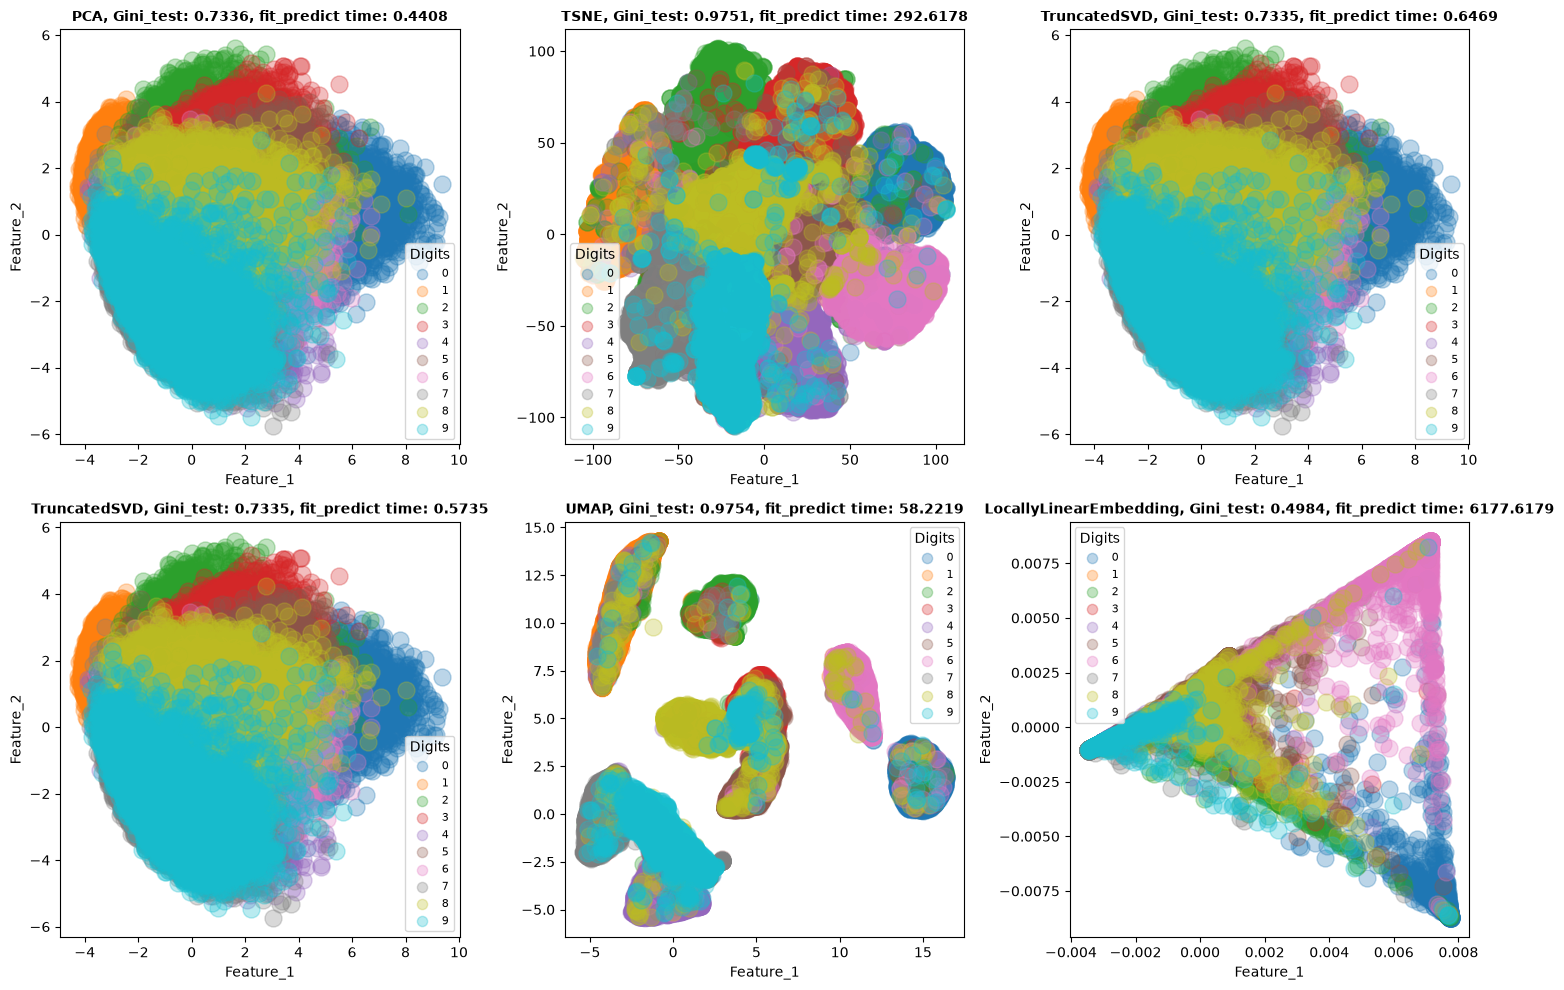

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  

for idx, reducer in enumerate(reducers):
    reducer_name = reducer.__class__.__name__
    start_time = time.time()
    X_reduced = reducer.fit_transform(X=X)
    fit_time = round(time.time() - start_time, 4)

    if reducer_name == "UMAP":
        model_to_save = reducer

    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, y, test_size=0.2, random_state=42
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )
    LogReg = LogisticRegression(random_state=42)
    LogReg.fit(X=X_train, y=y_train)

    for X_, y_, name in (
        (X_train, y_train, f"train {reducer_name}"),
        (X_valid, y_valid, f"valid {reducer_name}"),
        (X_test, y_test, f"test {reducer_name}"),
    ):
        # dont use [:, 1] its multiclass clsf
        y_pred = LogReg.predict_proba(X=X_)
        gini = round(
            2
            * roc_auc_score(
                y_true=y_, y_score=y_pred, multi_class="ovr", average="macro"
            )
            - 1,
            4,
        )

        reducers_out.loc[len(reducers_out)] = {
            "model": name,
            "Gini": gini,
            "Fit_time": fit_time,
        }

    # add empty row
    reducers_out.loc[len(reducers_out)] = {
        "model": "",
        "Gini": "",
        "Fit_time": "",
    }

    ax = axes[idx]

    for digit in np.unique(y):
        mask = y == digit
        ax.scatter(
            X_reduced[mask, 0], X_reduced[mask, 1], label=digit, alpha=0.3, s=150
        )

    ax.set_xlabel("Feature_1")
    ax.set_ylabel("Feature_2")
    ax.set_title(
        f"{reducer_name}, Gini_test: {gini}, fit_predict time: {fit_time}",
        fontsize=10,
        fontweight="bold",
    )
    ax.legend(title="Digits", title_fontsize=10, fontsize=8, markerscale=0.6)

plt.tight_layout()
plt.show()

##### 3.4 Propose metrics and compare models based on how well they separate digit classes.

In [17]:
# first approach visual: the absense of class overlapping
reducers_out.reset_index(drop=True)

,model,Gini,Fit_time
0,train PCA,0.7318,0.4408
1,valid PCA,0.7279,0.4408
2,test PCA,0.7336,0.4408
3,,,
4,train TSNE,0.976,292.6178
5,valid TSNE,0.9771,292.6178
6,test TSNE,0.9751,292.6178
7,,,
8,train TruncatedSVD,0.7318,0.6469
9,valid TruncatedSVD,0.7279,0.6469


#### Save one of the models from the "Visualizations" part of the task. <br>Your peer will load it and use it to compress one of the handwritten digits. <br>The compressed vector should have the same values.

In [18]:
joblib.dump(model_to_save, "umap_model.joblib")
# check
time.sleep(2)
loaded_model = joblib.load("umap_model.joblib")

digit = X[42:43]

compressed_original = model_to_save.transform(digit)
compressed_loaded = loaded_model.transform(digit)

print("Vectors equal:", np.allclose(compressed_original, compressed_loaded))

Vectors equal: True


#### 4. Image compression using SVD

##### 4.1 Select 3 random grayscale images and load them into matrix using Python.

##### 4.2 Decompose the matrix using SVD.

##### 4.3 Vary the rank, compute a low-rank approximation of the original matrix, and plot the recovered image.<br> Use up to 10 different ranks. <br>What does the singular value spectrum look like and how many modes are needed for good image reconstruction?

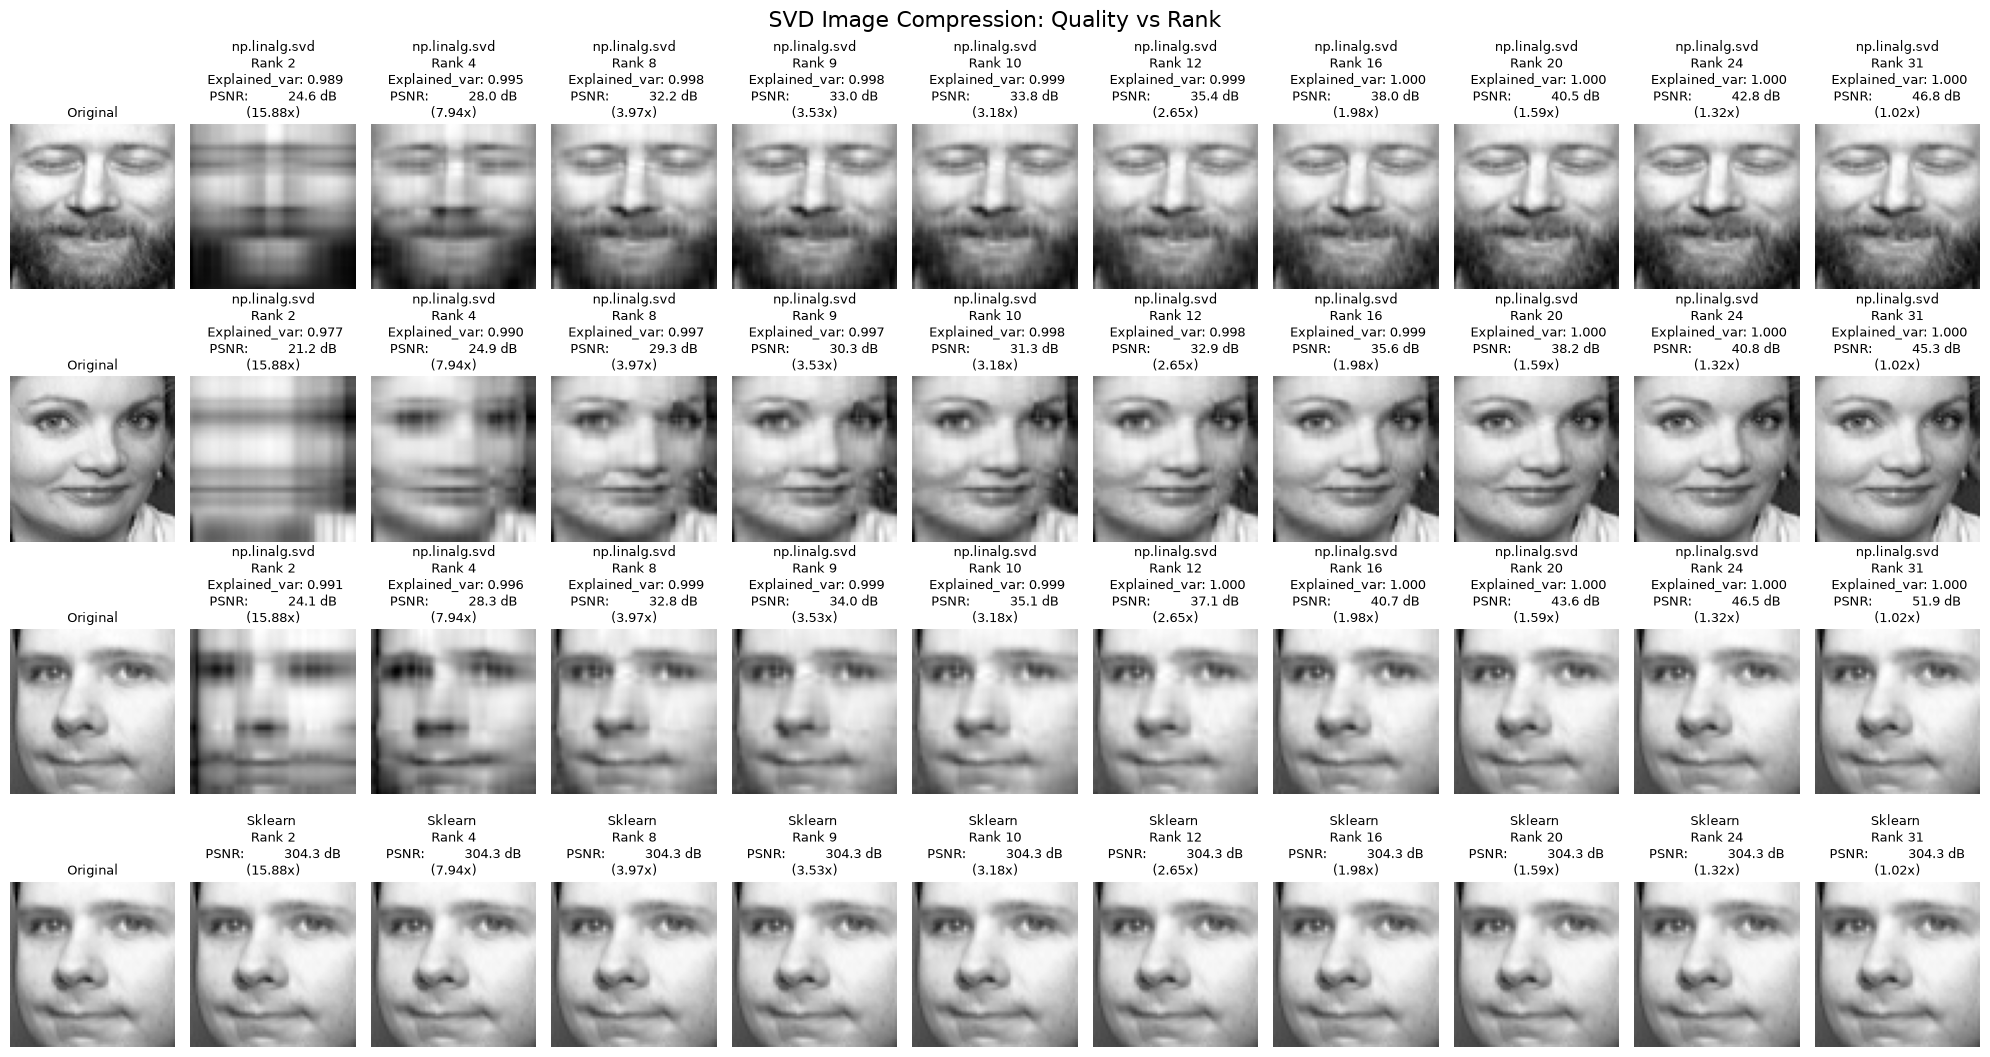

In [19]:
X, y = fetch_openml("Olivetti_Faces", version=1, return_X_y=True)
# 4.1 select 3 random img
height, width = 64, 64
X = X.sample(3, random_state=45)
X_train = np.asarray(X).reshape(-1, height, width)

fig, ax = plt.subplots(nrows=4, ncols=11, figsize=(20, 11))

variance_data = []
ranks = [2, 4, 8, 9, 10, 12, 16, 20, 24, 31]

for num, img in enumerate(X_train):
    ax[num, 0].imshow(img, cmap="gray")
    ax[num, 0].set_title("Original", fontsize=9, pad=5)
    ax[num, 0].axis("off")

    if num == 2:
        ax[num + 1, 0].imshow(img, cmap="gray")
        ax[num + 1, 0].set_title("Original", fontsize=9, pad=5)
        ax[num + 1, 0].axis("off")

for r_num, rank in enumerate(ranks):
    # calc comression
    original_size = height * width
    compressed_size = rank * (height + width + 1)
    compression_ratio = original_size / compressed_size

    for num, img in enumerate(X_train):
        if num == 2:
            # 4.2 decompose using svd (sklearn approach)
            # svd from sklearn (cant calc explained var correctly for flat img)

            svd = TruncatedSVD(n_components=rank, random_state=42)
            img_flat = img.reshape(1, -1)
            img_transformed = svd.fit_transform(img_flat)
            img_reconstructed = svd.inverse_transform(img_transformed)
            img_reconstructed_2d = img_reconstructed.reshape(height, width)
            mse = np.mean((img - img_reconstructed.reshape(height, width)) ** 2)
            # calc PSNR (Peak Signal-to-Noise Ratio = Visual Quality)
            psnr = 20 * np.log10(1 / np.sqrt(mse)) if mse > 0 else float("inf")

            ax[num + 1, r_num + 1].imshow(img_reconstructed_2d, cmap="gray")
            ax[num + 1, r_num + 1].set_title(
                f"Sklearn \nRank {rank}\nPSNR:          {psnr:.1f} dB\n({compression_ratio:.2f}x)",
                fontsize=9,
                pad=5,
            )
            ax[num + 1, r_num + 1].axis("off")

        # 4.2 decompose using svd
        U, s, Vt = np.linalg.svd(img, full_matrices=False)

        S = np.zeros((U.shape[0], Vt.shape[0]))
        S[:rank, :rank] = np.diag(s[:rank])
        img_reconstructed = U @ S @ Vt
        # calc PSNR (Peak Signal-to-Noise Ratio = Visual Quality)
        mse = np.mean((img - img_reconstructed) ** 2)
        psnr = 20 * np.log10(1 / np.sqrt(mse)) if mse > 0 else float("inf")

        # calc Explained Variance (≠ Visual Quality)
        total_variance = np.sum(s**2)
        explained_variance = np.sum(s[:rank] ** 2) / total_variance
        variance_data.append(
            {"rank": rank, "image": num, "explained_variance": explained_variance}
        )

        ax[num, r_num + 1].imshow(img_reconstructed, cmap="gray")
        ax[num, r_num + 1].set_title(
            f"np.linalg.svd\nRank {rank}\n Explained_var: {explained_variance:.3f}\nPSNR:          {psnr:.1f} dB\n({compression_ratio:.2f}x)",
            fontsize=9,
            pad=5,
        )
        ax[num, r_num + 1].axis("off")

plt.suptitle("SVD Image Compression: Quality vs Rank", fontsize=16, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

##### 4.4 Plot the distribution of explained variance versus rank. Explain what "explained variance" is.

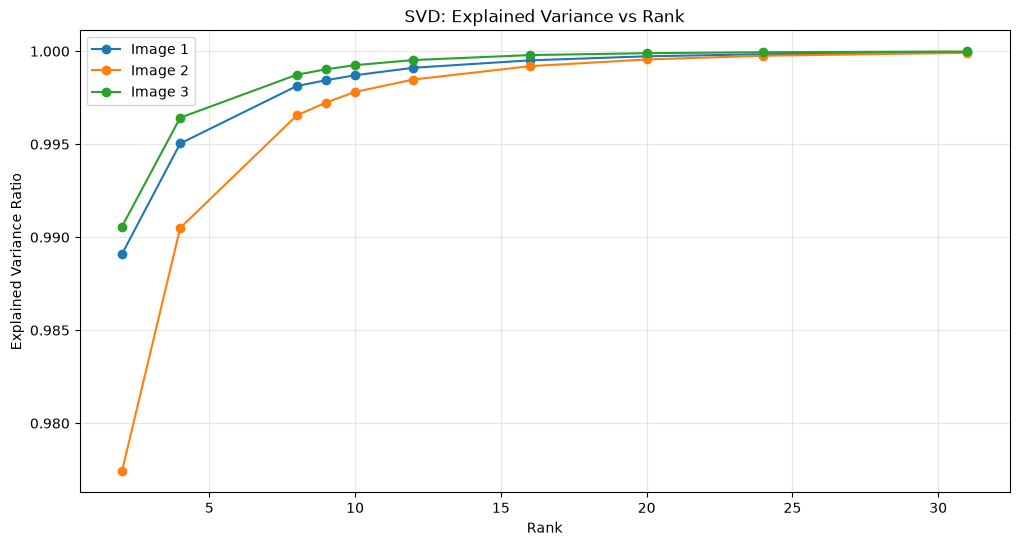

In [20]:
variance_df = pd.DataFrame(variance_data)

plt.figure(figsize=(12, 6))
for img_num in range(3):
    img_data = variance_df[variance_df["image"] == img_num]
    plt.plot(
        img_data["rank"],
        img_data["explained_variance"],
        marker="o",
        label=f"Image {img_num+1}",
    )

plt.xlabel("Rank")
plt.ylabel("Explained Variance Ratio")
plt.title("SVD: Explained Variance vs Rank")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### $\small \text{Explained Variance}_k = \frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{r} \sigma_i^2}$
$k$ = rank, а $\sigma_i$ - singular values<br>
Explained Variance measures how much of the total variance in the original data is captured by the principal components (or SVD components) we keep. <br>
It tells us what percentage of the original information is preserved when we reduce dimensionality.

<!-- Объяснённая дисперсия измеряет, какая часть общей дисперсии исходных данных охватывается главными компонентами (или компонентами SVD), которые мы сохраняем. <br>
Она показывает, какой процент исходной информации сохраняется при уменьшении размерности. -->

#### 5. Background detection using SVD

##### 5.1 Load "Video_008.avi" (source — bmc_real.zip).

In [21]:
# 320x240
path = "data/Background_Models_Challenge/real/Video_008/Video_008.avi"
vidcap = cv2.VideoCapture(path)

##### 5.2 Represent the video as a matrix and decompose it using SVD.

In [22]:
frames = []
while True:
    ret, frame = vidcap.read()
    if not ret:
        break
    # Convert to grayscale and flatten
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray_frame.flatten())

# free mem
vidcap.release()

video_matrix = np.array(frames)
video_matrix.shape

(792, 76800)

##### 5.3 Reconstruct the first frame using low-rank approximation. What rank should you use to get the background?

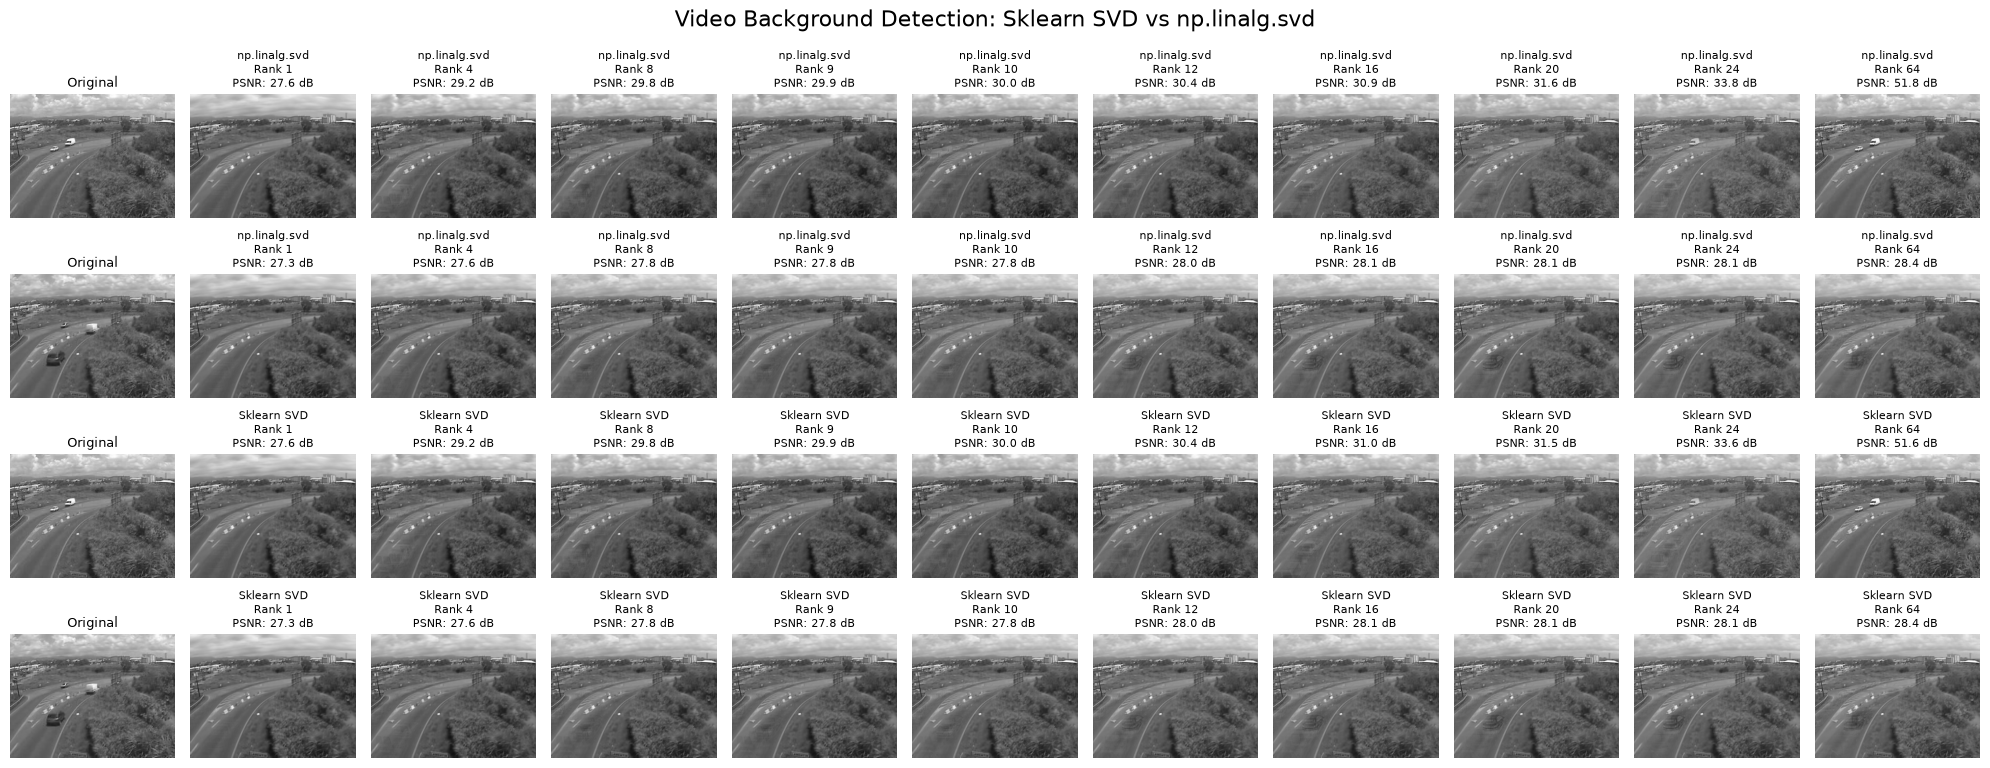

In [23]:
random_frames_indices = [0, 120]
height, width = 240, 320

n_samples = 100
video_samples = video_matrix[:n_samples]
video_matrix_flat = video_samples.reshape(n_samples, -1)

ranks = [1, 4, 8, 9, 10, 12, 16, 20, 24, 64]

fig, ax = plt.subplots(nrows=4, ncols=len(ranks) + 1, figsize=(20, 8))
# plot original frames
for num, idx in enumerate(random_frames_indices):
    img = video_matrix[idx]
    ax[num, 0].imshow(img.reshape(height, width), cmap="gray")
    ax[num, 0].set_title("Original", fontsize=9, pad=5)
    ax[num, 0].axis("off")

    ax[num + 2, 0].imshow(img.reshape(height, width), cmap="gray")
    ax[num + 2, 0].set_title("Original", fontsize=9, pad=5)
    ax[num + 2, 0].axis("off")

for r_num, rank in enumerate(ranks):
    svd_sklearn = TruncatedSVD(n_components=rank, random_state=42)
    bg_sklearn_all = svd_sklearn.fit_transform(video_matrix_flat)
    bg_sklearn_all = svd_sklearn.inverse_transform(bg_sklearn_all)
    bg_sklearn_all = bg_sklearn_all.reshape(n_samples, height, width)

    U_multi, s_multi, Vt_multi = np.linalg.svd(video_matrix_flat, full_matrices=False)
    bg_linalg_all = (
        U_multi[:, :rank] @ np.diag(s_multi[:rank]) @ Vt_multi[:rank, :]
    ).reshape(n_samples, height, width)

    for num, idx in enumerate(random_frames_indices):
        original_frame = video_matrix[idx].reshape(height, width)

        if idx < n_samples:
            bg_sklearn_frame = bg_sklearn_all[idx]
            bg_linalg_frame = bg_linalg_all[idx]
        else:
            frame_flat = video_matrix[idx].reshape(1, -1)
            bg_sklearn_frame = svd_sklearn.inverse_transform(
                svd_sklearn.transform(frame_flat)
            ).reshape(height, width)
            bg_linalg_frame = (
                frame_flat @ Vt_multi[:rank, :].T @ Vt_multi[:rank, :]
            ).reshape(height, width)

        mse_sklearn = np.mean((original_frame - bg_sklearn_frame) ** 2)
        psnr_sklearn = (
            20 * np.log10(255 / np.sqrt(mse_sklearn))
            if mse_sklearn > 0
            else float("inf")
        )

        mse_multi = np.mean((original_frame - bg_linalg_frame) ** 2)
        psnr_multi = (
            20 * np.log10(255 / np.sqrt(mse_multi)) if mse_multi > 0 else float("inf")
        )

        # plot bg reconstructed
        ax[num, r_num + 1].imshow(bg_linalg_frame, cmap="gray")
        ax[num, r_num + 1].set_title(
            f"np.linalg.svd\nRank {rank}\nPSNR: {psnr_multi:.1f} dB", fontsize=8, pad=5
        )
        ax[num, r_num + 1].axis("off")

        ax[num + 2, r_num + 1].imshow(bg_sklearn_frame, cmap="gray")
        ax[num + 2, r_num + 1].set_title(
            f"Sklearn SVD\nRank {rank}\nPSNR: {psnr_sklearn:.1f} dB", fontsize=8, pad=5
        )
        ax[num + 2, r_num + 1].axis("off")

plt.suptitle(
    "Video Background Detection: Sklearn SVD vs np.linalg.svd", fontsize=16, y=0.98
)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

What rank should you use to get the background? <br>
Rank 1 - gets proper background frame.

#### 6. Bonus part

##### 6.1 Using the face expression recognition dataset, fit the dimensionality reduction model to compress faces.

In [24]:
def create_img_df(img_dir_path: str, df_len: int = 5_000) -> np.array:
    img_df: list = []
    for num, filename in enumerate(os.listdir(img_dir_path)):
        if num == df_len:
            break
        image = cv2.imread(os.path.join(img_dir_path, filename))

        gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        img_df.append(gray_img.flatten())

    return np.array(img_df)


path_train: str = "data/Face_expression/images/train/{name}"
path_valid: str = "data/Face_expression/images/validation/{name}"

# using only 5000 (def val)
train_happy_df = create_img_df(path_train.format(name="happy"))
valid_happy_df = create_img_df(path_valid.format(name="happy"))

train_sad_df = create_img_df(path_train.format(name="sad"))
valid_sad_df = create_img_df(path_valid.format(name="sad"))

sample_img = cv2.imread(
    os.path.join(
        path_train.format(name="happy"), os.listdir(path_train.format(name="happy"))[0]
    )
)
height, width = sample_img.shape[:2]

combined_train = np.vstack([train_happy_df, train_sad_df])
pca = PCA(n_components=200, random_state=42)
pca.fit(combined_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to 

##### 6.2 Using the representations, try to turn a sad face into a smiley face and vice versa.

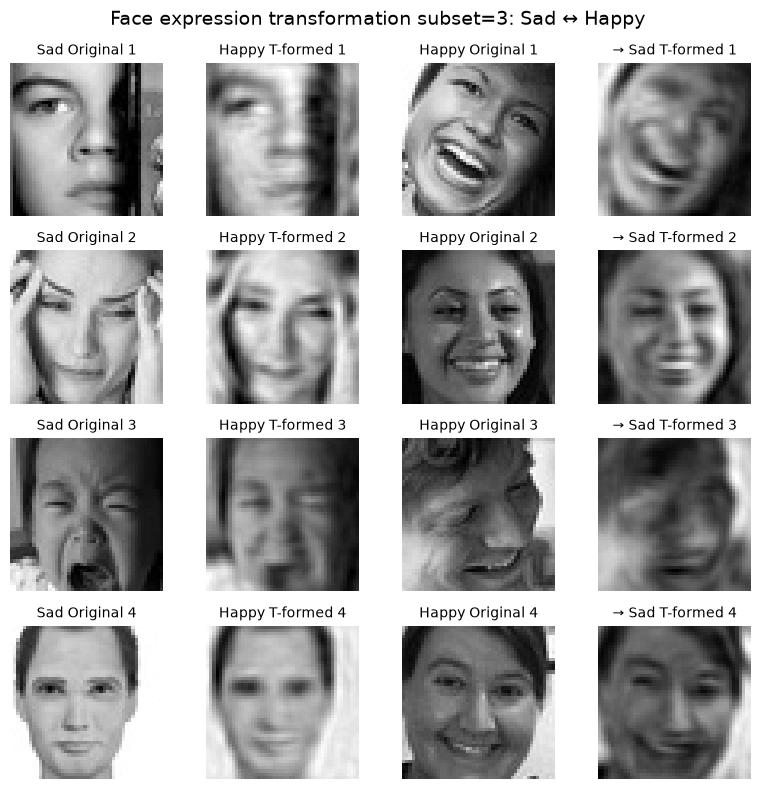

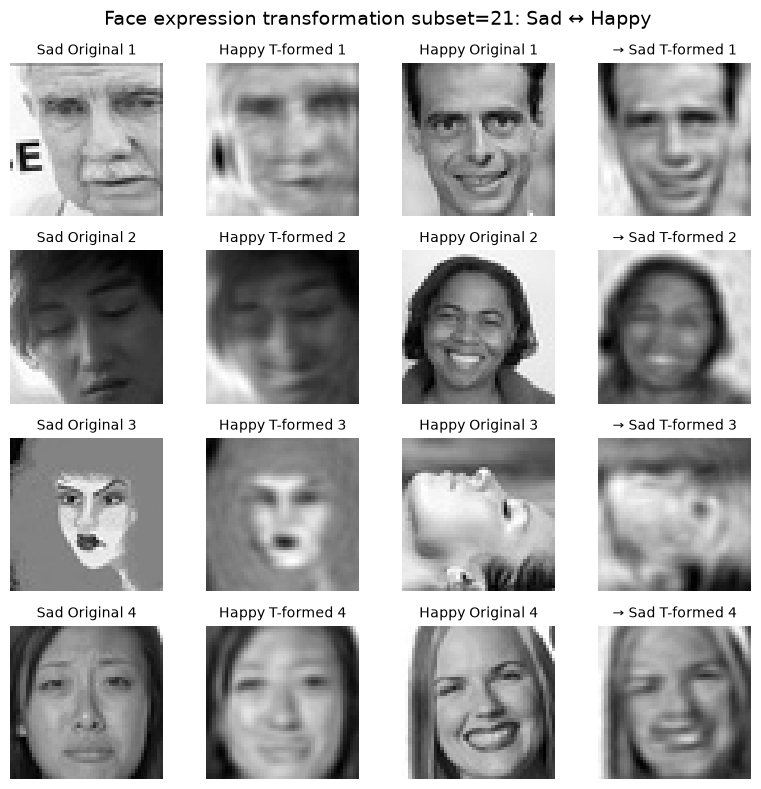

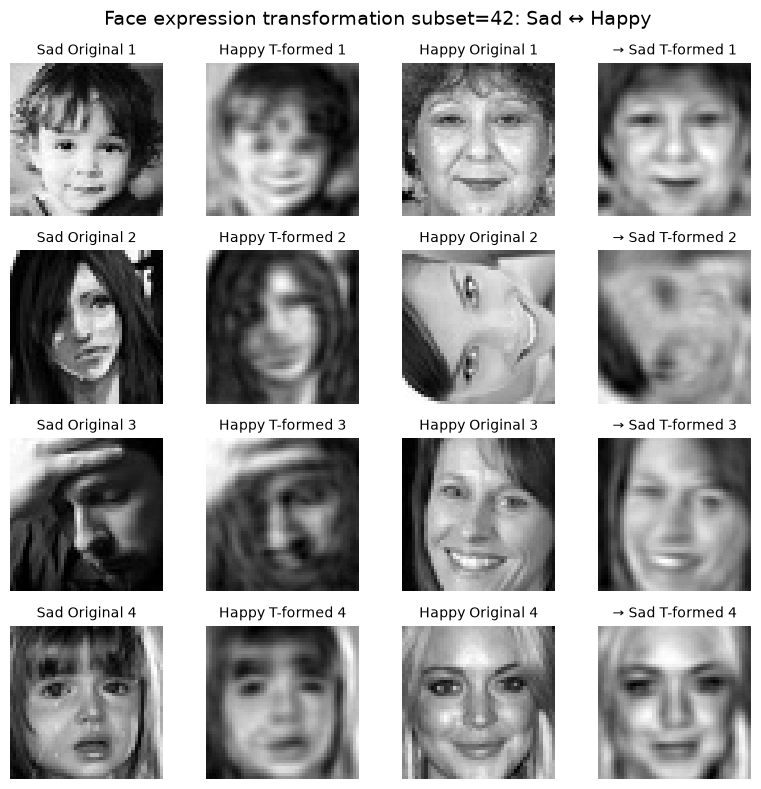

In [25]:
happy_faces = pca.transform(train_happy_df)
sad_faces = pca.transform(train_sad_df)

happy_avg = np.mean(happy_faces, axis=0)
sad_avg = np.mean(sad_faces, axis=0)


def transform_expression(source_image, source_avg, target_avg):
    source_face = pca.transform(source_image.reshape(1, -1))
    target_face = source_face - source_avg + target_avg
    return pca.inverse_transform(target_face)


for subset in [3, 21, 42]:
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))

    for i in range(4):
        sad_img, happy_img = valid_sad_df[subset:][i], valid_happy_df[subset:][i]
        happy_transformed = transform_expression(sad_img, sad_avg, happy_avg)
        sad_transformed = transform_expression(happy_img, happy_avg, sad_avg)

        for j, (img, title) in enumerate(
            [
                (sad_img, f"Sad Original {i+1}"),
                (happy_transformed, f"Happy T-formed {i+1}"),
                (happy_img, f"Happy Original {i+1}"),
                (sad_transformed, f"→ Sad T-formed {i+1}"),
            ]
        ):
            axes[i, j].imshow(img.reshape(height, width), cmap="gray")
            axes[i, j].set_title(title, fontsize=10)
            axes[i, j].axis("off")

    plt.suptitle(f"Face expression transformation {subset=}: Sad ↔ Happy ", fontsize=14)
    plt.tight_layout()
    plt.show()

#### * Sources
- Kevin P. Murphy "Probabilistic ML"

In [26]:
total_seconds = time.time() - notebook_time
print(f"{int(total_seconds // 60)}m {round(total_seconds % 60, 1)}s")

116m 55.9s
